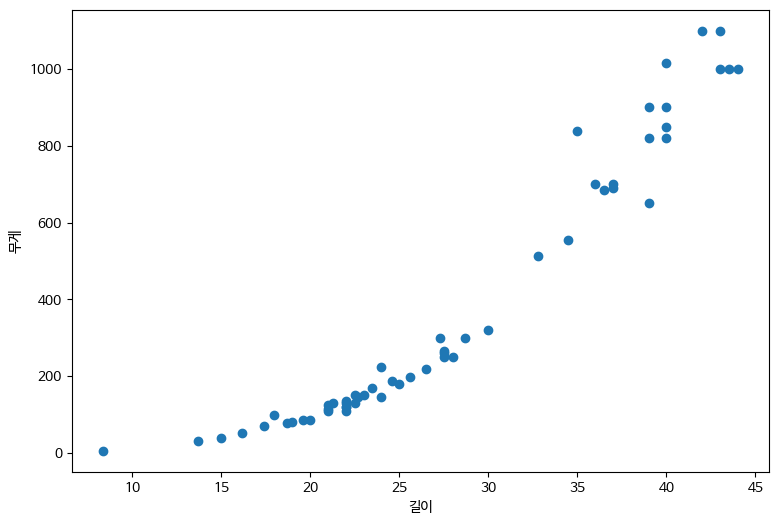

In [1]:
#k최근접 이웃회귀
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

url=r'c:\Windows\Fonts\NanumBarunGothic.ttf'
fm.fontManager.addfont(url)
plt.rc('font', family=fm.FontProperties(fname=url).get_name())

import numpy as np
perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 21.0,
       21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 22.5, 22.7,
       23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 27.3, 27.5, 27.5,
       27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 36.5, 36.0, 37.0, 37.0,
       39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 40.0, 42.0, 43.0, 43.0, 43.5,
       44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))
plt.scatter(perch_length, perch_weight)
plt.xlabel('길이')
plt.ylabel('무게')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = \
    train_test_split(perch_length, perch_weight, random_state=42)
    
# 입력 데이터를 2차원 넘파이 배열로 - np.reshape
train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)


(42, 1) (14, 1)


In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knr = KNeighborsRegressor(n_neighbors=3)
knr.fit(train_input, train_target)
knr.score(test_input, test_target)

from sklearn.metrics import mean_absolute_error #metrcis 패키지 편차 절댓값 평균
test_prediction = knr.predict(test_input)
mean_absolute_error(test_target, test_prediction)

print(knr.score(test_input, test_target))
print(knr.score(train_input, train_target))
knr.predict([[6]])



0.9746459963987609
0.9804899950518966


array([47.33333333])

C:\Users\박중현\AppData\Local\Temp\ipykernel_11864\3657401907.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


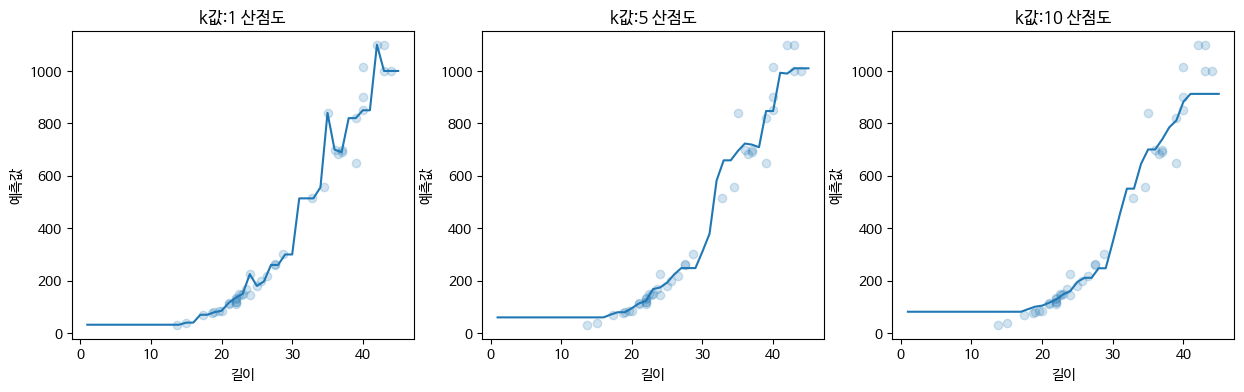

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
kn = KNeighborsRegressor()

test_sample = np.arange(1, 46).reshape(-1, 1)
a=[1,5,10]

fig, axs = plt.subplots(1, 3, figsize=(5*len(a), 4))
for n in a:
    kn.n_neighbors = n
    kn.fit(train_input, train_target)
    sample_result = kn.predict(test_sample)
    
    i = a.index(n)
    axs[i].scatter(train_input, train_target, alpha=0.2)
    axs[i].plot(test_sample[:, 0], sample_result)
    axs[i].set_title(f'k값:{n} 산점도')
    axs[i].set_xlabel('길이')
    axs[i].set_ylabel('예측값')

fig.savefig('k_최근접이웃_산점도.png', dpi=200, bbox_inches='tight')
fig.show()
    